# Forecasting Tomorrow's Vol \U0001F52E
### You cannot predict the return. You can absolutely predict the size of it.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

Nobody can tell you whether the market goes up or down tomorrow. Everybody can tell you
whether it will be a quiet day or a wild one — volatility clusters, and that is the most
reliable pattern in finance. So four models line up to forecast it: a plain 21-day average, a
one-line exponential filter, a Nobel-winning GARCH, and the realised-volatility literature's
workhorse. This notebook asks which one you should actually use.

> \U0001F4D3 **This is the plain-language layer.** The likelihood fitting, the QLIKE scores
> and the Diebold-Mariano tests are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is volatility forecastable? | Overwhelmingly yes — far more so than returns will ever be. |
| Does the Nobel-winning model beat the spreadsheet average? | Yes, out of sample, on most tapes. |
| By a lot? | No. And a single line of exponential smoothing gets most of the way there. |
| So what should you use? | EWMA if you want free and good; GARCH or HAR if the last few percent matter. |

## 1 · The claim

> *"Returns are unpredictable, but risk is not. Fit a proper conditional-volatility model and
> your risk numbers will be sharper than anything a rolling window can give you."*

This is the mainstream position of forty years of econometrics, and it is broadly right. The
part worth testing is *how much* sharper.

## 2 · So what?

Every position size, every stop, every risk limit and every option price is a function of a
volatility number. If the fancy model is 20% better, that is worth having. If it is 2% better,
the extra machinery is a liability — one more thing to fit, monitor and misconfigure.

In [2]:
from vol_forecast import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
spy = rets["SPY"]
print(f"as-of {data.AS_OF} | SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} returns, annualised vol {spy.std() * np.sqrt(252):.1%})")

as-of 2026-06-30 | SPY 1993-02-01 -> 2026-06-30 (8,410 returns, annualised vol 18.6%)


### Volatility clusters. Here is the whole premise, in one picture.

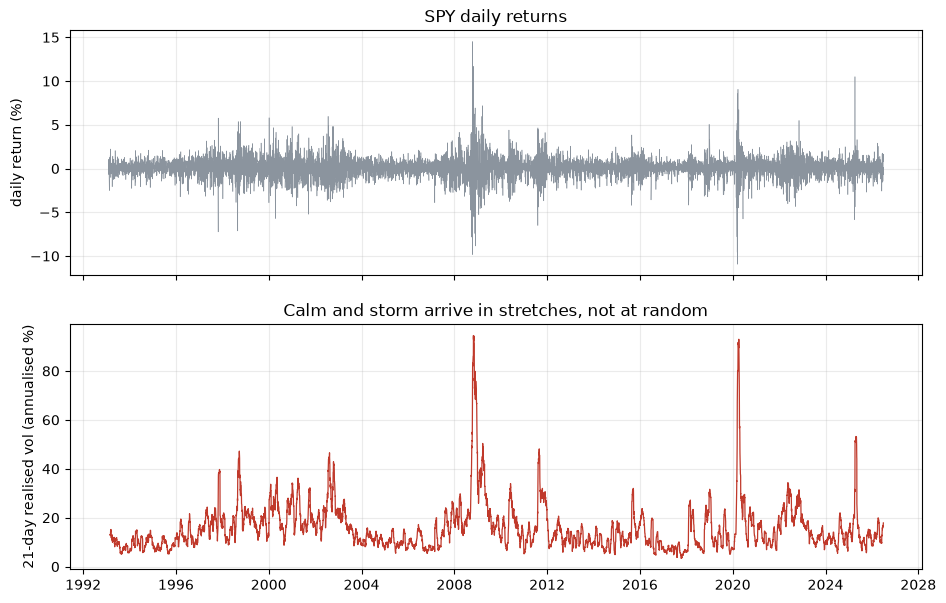

autocorrelation of |returns| at lag 1: 0.275   at lag 21: 0.196
autocorrelation of returns themselves at lag 1: -0.082


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(spy.index, spy * 100, lw=0.4, color="#8b949e")
axes[0].set_ylabel("daily return (%)"); axes[0].set_title("SPY daily returns")
roll = np.sqrt(st.rolling_sd_var(spy) * 252) * 100
axes[1].plot(roll.index, roll, lw=0.9, color="#c0392b")
axes[1].set_ylabel("21-day realised vol (annualised %)")
axes[1].set_title("Calm and storm arrive in stretches, not at random")
plt.show()
print(f"autocorrelation of |returns| at lag 1: {spy.abs().autocorr(1):.3f}   "
      f"at lag 21: {spy.abs().autocorr(21):.3f}")
print(f"autocorrelation of returns themselves at lag 1: {spy.autocorr(1):+.3f}")

> \U0001F52C **For the quants.** That contrast — a big number for |r| and a rounding error for
> r — is the entire justification for the volatility-modelling industry.

## 3 · How would we even know?

Each model gets the same data, is refitted every quarter on everything available up to that
point, and forecasts the next day, week or month. Then we score the forecasts on data the
model never saw. No peeking, and the scoring rule (QLIKE) is one that does not fall apart when
the thing being predicted is measured with noise.

## 4 · The teardown

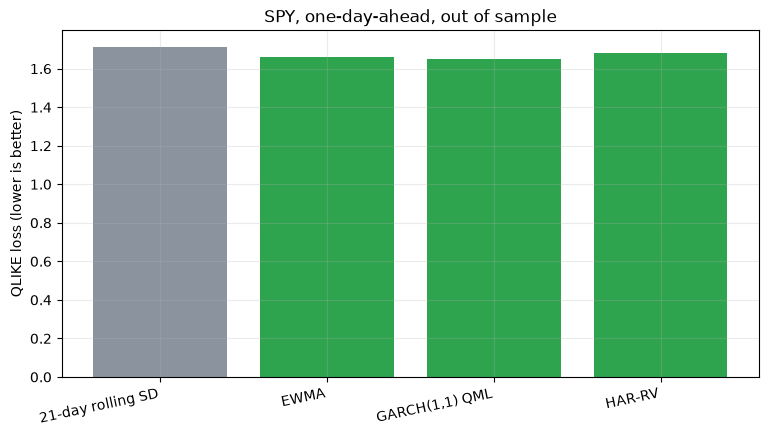

,qlike,mse,dm_vs_rolling,p_vs_rolling
21-day rolling SD,1.7128,0.0000,NaN,NaN
EWMA (lambda = 0.94),1.6589,0.0000,5.5263,0.0000
"GARCH(1,1) QML",1.6478,0.0000,4.6113,0.0000
HAR-RV (Corsi 2009),1.6796,0.0000,1.8741,0.0609


In [4]:
ALL = {tk: st.tournament(r, 1, 756, 126) for tk, r in rets.items()}   # reused below
t = ALL["SPY"]
show = t[["qlike", "mse", "dm_vs_rolling", "p_vs_rolling"]].copy()
show.index = [st.MODEL_LABEL[m] for m in show.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#8b949e" if m == "rolling21" else "#2ea44f" for m in t.index]
ax.bar([st.MODEL_LABEL[m].split(" (")[0] for m in t.index], t["qlike"], color=colors)
ax.set_ylabel("QLIKE loss (lower is better)")
ax.set_title("SPY, one-day-ahead, out of sample")
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
plt.show()
show.round(4)

The bars are close together. That is the finding: every sensible model knows the same thing,
and the difference between the best and the baseline is a few percent of a loss function, not
a different worldview.

### What the models actually look like when they disagree

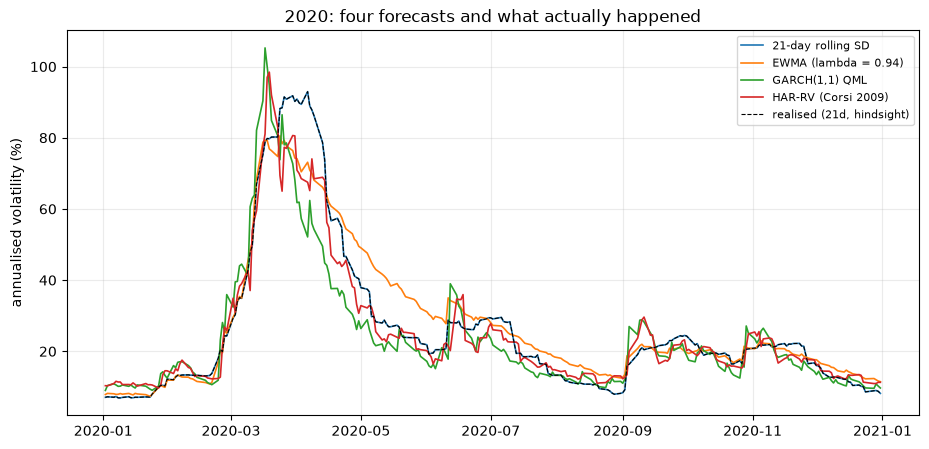

In [5]:
f = st.forecasts(spy, horizon=1, burn=756, refit_every=126)
win = f.loc["2020-01-01":"2020-12-31"]
fig, ax = plt.subplots(figsize=(11, 5))
for m in st.MODELS:
    ax.plot(win.index, np.sqrt(win[m] * 252) * 100, lw=1.2, label=st.MODEL_LABEL[m])
realised = np.sqrt(st.rolling_sd_var(spy) * 252) * 100
ax.plot(realised.loc[win.index].index, realised.loc[win.index], color="k", lw=0.8, ls="--",
        label="realised (21d, hindsight)")
ax.set_ylabel("annualised volatility (%)")
ax.set_title("2020: four forecasts and what actually happened")
ax.legend(fontsize=8)
plt.show()

The rolling window is the slow one — it steps up a month late and steps down a month late,
because every observation inside it has the same weight. That lag is precisely what the other
three models are built to remove.

## 5 · The verdict

**Signal: Real.** Out of sample at the one-day horizon, **GARCH(1,1) QML** is the best model on **5 of 6** tapes, and something beats the 21-day rolling baseline on **6 of 6** — pooled Diebold-Mariano **+4.65** against a baseline that costs nothing to compute. The ordering is stable across horizons (1 / 5 / 21 days) and reproduced on simulated data where the true variance is observable.

**Usefulness: Fragile.** The pooled QLIKE improvement over the rolling window is **3.5%**. EWMA — one parameter, never fitted — captures 89% of what the fitted GARCH achieves, and the fitted models cost a maximum-likelihood optimisation every quarter. The gap between the best and worst *sensible* model is smaller than the gap between using any of them and using none.

## 6 · Is it worth the machinery?

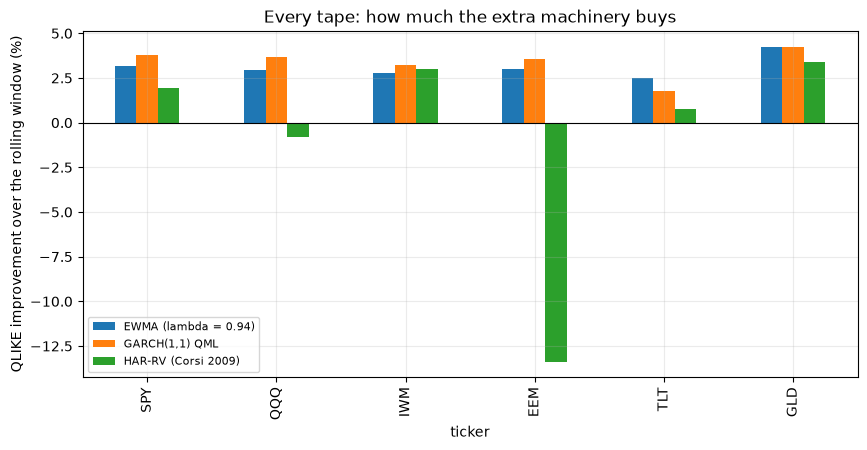

,EWMA (lambda = 0.94),"GARCH(1,1) QML",HAR-RV (Corsi 2009)
ticker,,,
SPY,3.1000,3.8000,1.9000
QQQ,3.0000,3.7000,-0.8000
IWM,2.8000,3.2000,3.0000
EEM,3.0000,3.6000,-13.4000
TLT,2.5000,1.8000,0.8000
GLD,4.2000,4.3000,3.4000


In [6]:
rows = []
for tk, tt in ALL.items():
    base = tt.loc["rolling21", "qlike"]
    rows.append({"ticker": tk,
                 **{st.MODEL_LABEL[m]: 1 - tt.loc[m, "qlike"] / base for m in st.MODELS}})
gain = pd.DataFrame(rows).set_index("ticker").drop(columns=[st.MODEL_LABEL["rolling21"]])
fig, ax = plt.subplots(figsize=(10, 4.5))
(gain * 100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("QLIKE improvement over the rolling window (%)")
ax.set_title("Every tape: how much the extra machinery buys")
ax.legend(title="", fontsize=8)
plt.show()
(gain * 100).round(1)

## 7 · Going further \U0001F6AA

- **Combine them.** The forecasting literature's most durable result is that a simple average
  of models beats the best single model. It would beat everything above, too.
- **Asymmetry.** GJR-GARCH and EGARCH let a fall raise volatility more than a rise — this
  desk's study **993** measures that effect directly.
- **Intraday data** replaces the noisy target with realised variance and roughly doubles
  everyone's apparent skill.